# Etapa 3 — Baseline e estratégia algorítmica

O enunciado pede, **no notebook**: (a) a métrica de conversão de uma regra fixa (baseline)
e (b) o algoritmo adaptativo mostrando métrica **superior ao baseline**.

Todo o código real vive em `src/bm/` — este notebook só orquestra e exibe. É de propósito:
a API (Etapa 5) e o golden set (Etapa 4.2) chamam exatamente estas funções, então não pode
existir uma segunda implementação copiada aqui (evita train/serving skew).

Pré-requisito: `uv run python -m bm.data_prep` (Etapa 2). Rodar da raiz do repositório.

In [1]:
import os

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")  # tudo abaixo assume a raiz do repo

import joblib
import pandas as pd

from bm.data_prep import CONTEXT_FEATURES, arm_stats
from bm.evaluation import build_metrics_table, summarize_policy
from bm.experiments.run_thompson_replay import summarize_across_seeds
from bm.experiments.train import train_bandit
from bm.models.bandit import EpsilonGreedy, ThompsonSampling

frame = pd.read_parquet("data/processed/bandit_frame.parquet")
preprocessor = joblib.load("models/preprocessor.joblib")

print(f"{len(frame):,} linhas — ordem cronológica preservada (mai/2008 → nov/2010)")
frame.head(3)

41,176 linhas — ordem cronológica preservada (mai/2008 → nov/2010)


,arm,reward,job,marital,education,default,housing,loan,month,day_of_week,poutcome,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
0,telephone,0,housemaid,married,basic.4y,no,no,no,may,mon,nonexistent,56,1,0,1.1,93.994,-36.4,4.857,5191.0,False
1,telephone,0,services,married,high.school,unknown,no,no,may,mon,nonexistent,57,1,0,1.1,93.994,-36.4,4.857,5191.0,False
2,telephone,0,services,married,high.school,no,yes,no,may,mon,nonexistent,37,1,0,1.1,93.994,-36.4,4.857,5191.0,False


## 3.1 Baselines determinísticos

Duas políticas de controle, medidas direto no histórico — não simulam nada:

1. **Regra fixa ingênua**: sempre `telephone`.
2. **Melhor braço histórico (oráculo estático)**: sempre `cellular`. É o teto que o bandit
   persegue — mas note que ele só é conhecido *depois* de ver a base inteira; o bandit
   precisa descobrir isso sozinho.

In [2]:
stats = arm_stats(frame)
p_oracle = stats["conversao"].max()

print(f"Baseline regra fixa (telephone): {stats.loc['telephone', 'conversao']:.2%}")
print(f"Melhor braço histórico (cellular): {p_oracle:.2%}  <- oráculo")
stats

Baseline regra fixa (telephone): 5.23%
Melhor braço histórico (cellular): 14.74%  <- oráculo


,n,conversao,conversao_pct
arm,,,
cellular,26135,0.147389,14.74
telephone,15041,0.052324,5.23


## 3.2 / 3.3 Algoritmos adaptativos por replay

Avaliação **offline por replay (rejection sampling, Li et al. 2011)**: percorremos a base na
ordem; a cada cliente o bandit escolhe um braço; se coincidir com o braço realmente usado no
histórico, contabilizamos a recompensa e atualizamos o bandit — senão descartamos a linha,
porque não existe desfecho observável para a ação que não aconteceu.

3 seeds por política aqui, para o notebook rodar rápido. A tabela oficial do README usa 10
(`uv run python -m bm.evaluation`), que também registra cada rodada no MLflow (Etapa 7).

**Priors do Thompson**: `Normal(0, alpha² · I)` sobre os coeficientes de cada braço, `alpha=1.0`
— não-informativo, nenhum braço favorecido antes de ver dados.

In [3]:
SEEDS = [7, 42, 123]
N_FEATURES = preprocessor.transform(frame[CONTEXT_FEATURES].head(1)).shape[1]


def replay(criar_bandit, seeds=SEEDS):
    """Roda o replay uma vez por seed e devolve o agregado (média ± desvio)."""
    resultados = []
    for seed in seeds:
        bandit, rewards = train_bandit(
            criar_bandit(seed), frame, preprocessor, log_to_mlflow=False
        )
        resumo = summarize_policy(rewards, p_oracle)
        resultados.append({"seed": seed, **resumo})
        print(f"  seed={seed}: conversao={resumo['conversao']:.2%} regret={resumo['regret_final']:.0f}")
    return summarize_across_seeds(resultados)


print("Thompson Sampling:")
agregado_thompson = replay(lambda s: ThompsonSampling(alpha=1.0, n_features=N_FEATURES, seed=s))

print("\nEpsilon-Greedy (epsilon=0.1):")
agregado_epsilon = replay(lambda s: EpsilonGreedy(epsilon=0.1, seed=s))

Thompson Sampling:


  seed=7: conversao=12.53% regret=474


  seed=42: conversao=13.20% regret=328


  seed=123: conversao=12.83% regret=411

Epsilon-Greedy (epsilon=0.1):
  seed=7: conversao=11.19% regret=1287


  seed=42: conversao=11.33% regret=1220
  seed=123: conversao=11.23% regret=1266


## 3.4 Resultado: o adaptativo supera o baseline

In [4]:
tabela = build_metrics_table(frame, agregado_thompson, agregado_epsilon)
tabela

,Política,Conversão (replay),Regret acumulado,N amostras usadas
0,Regra fixa (telephone),5.23%,alto,15041
1,Melhor braço histórico (cellular),14.74%,0 (oráculo),26135
2,Epsilon-Greedy (epsilon=0.1) (média de 10 seeds),11.25% +/- 0.06pp,1257.8 +/- 28.0,36053
3,Thompson Sampling (média de 10 seeds),12.86% +/- 0.27pp,404.7 +/- 59.7,21490


In [5]:
base = stats.loc["telephone", "conversao"]
ts = agregado_thompson["conversao_media"]

print(f"Regra fixa (telephone) ....... {base:.2%}")
print(f"Thompson Sampling ............ {ts:.2%}")
print(f"Oráculo estático (cellular) .. {p_oracle:.2%}")
print()
print(f"Ganho sobre o baseline: {(ts / base - 1):.1%} relativo (+{(ts - base) * 100:.2f} p.p.)")
print(f"Distância do oráculo: {(p_oracle - ts) * 100:.2f} p.p. — o preço da exploração")

Regra fixa (telephone) ....... 5.23%
Thompson Sampling ............ 12.86%
Oráculo estático (cellular) .. 14.74%

Ganho sobre o baseline: 145.7% relativo (+7.62 p.p.)
Distância do oráculo: 1.88 p.p. — o preço da exploração


O Thompson **supera a regra fixa com folga** e chega perto do oráculo sem nunca ter recebido a
informação de qual braço é o melhor — descobre sozinho. Não encosta nos 14,74% porque parte das
rodadas ele ainda gasta testando `telephone`: é exploração, não erro.

O Epsilon-Greedy fica quase preso na taxa-base (~11,3%): com `epsilon=0.1` ele explora a uma taxa
fixa para sempre, enquanto o Thompson reduz a exploração automaticamente conforme a crença
sobre cada braço fica mais firme. É esse o trade-off que a Etapa 3.4 analisa.

## Figuras (geradas por `uv run python -m bm.exploration`)

conversao_acumulada.png


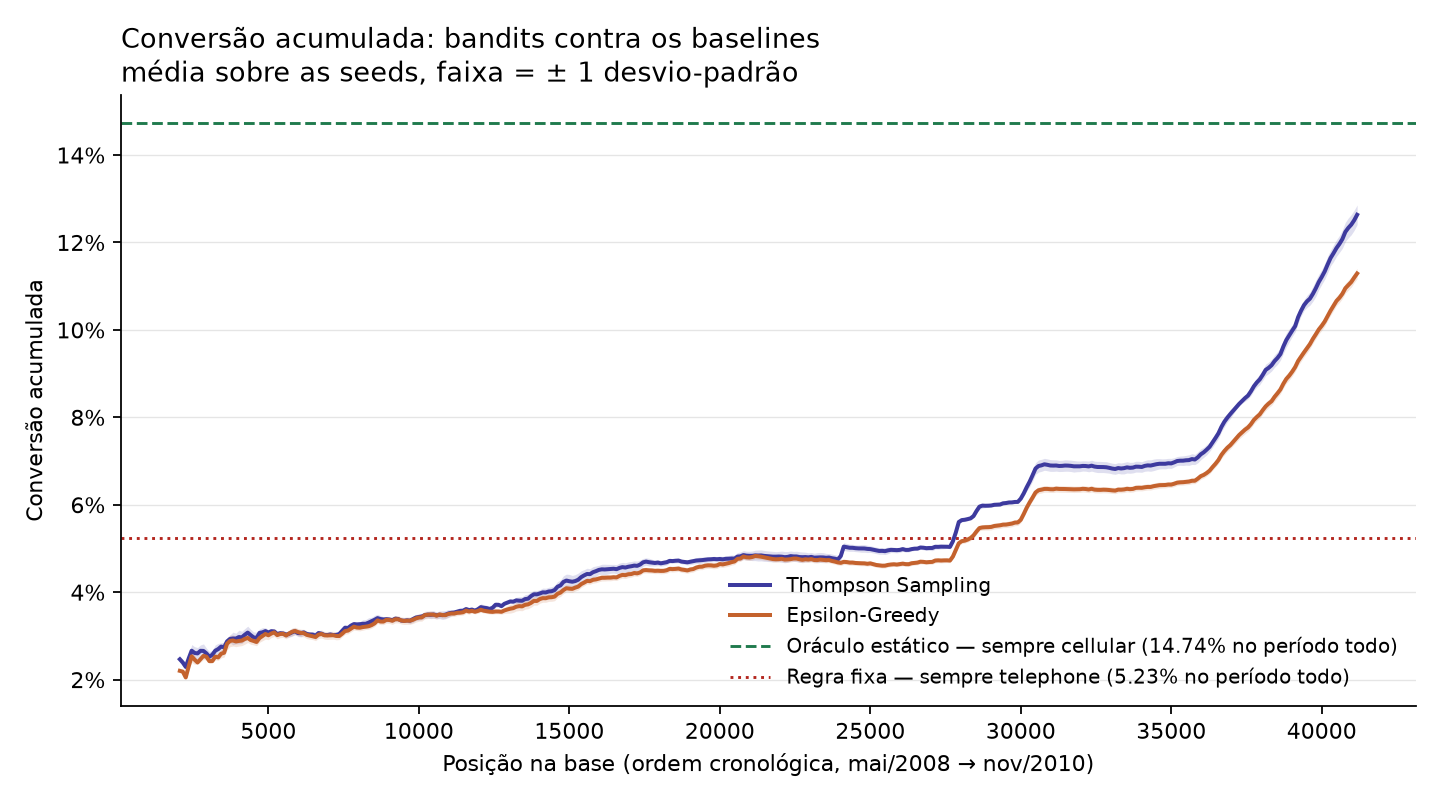

escolha_por_braco.png


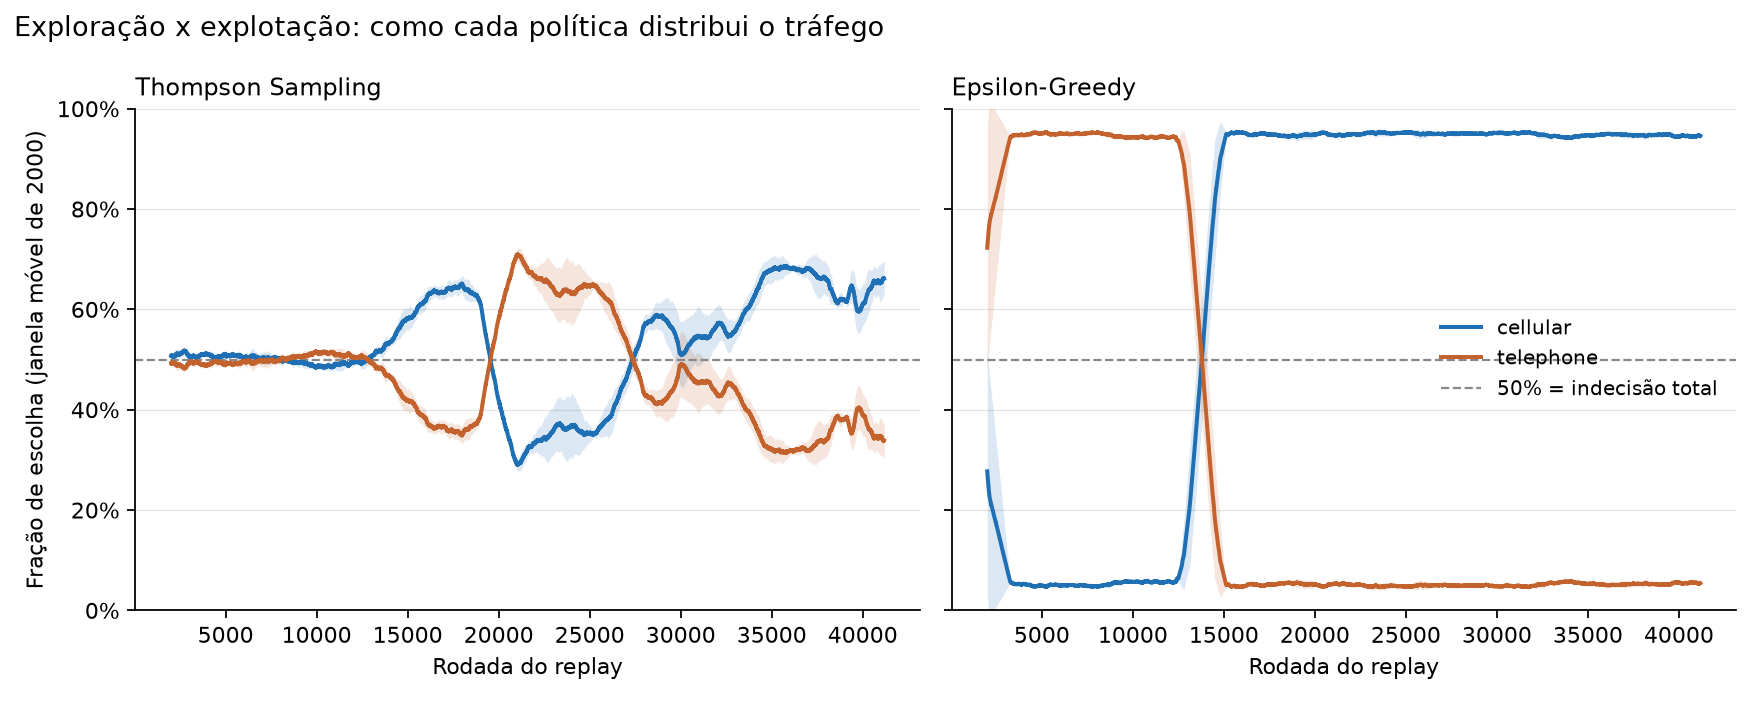

posterior_thompson.png


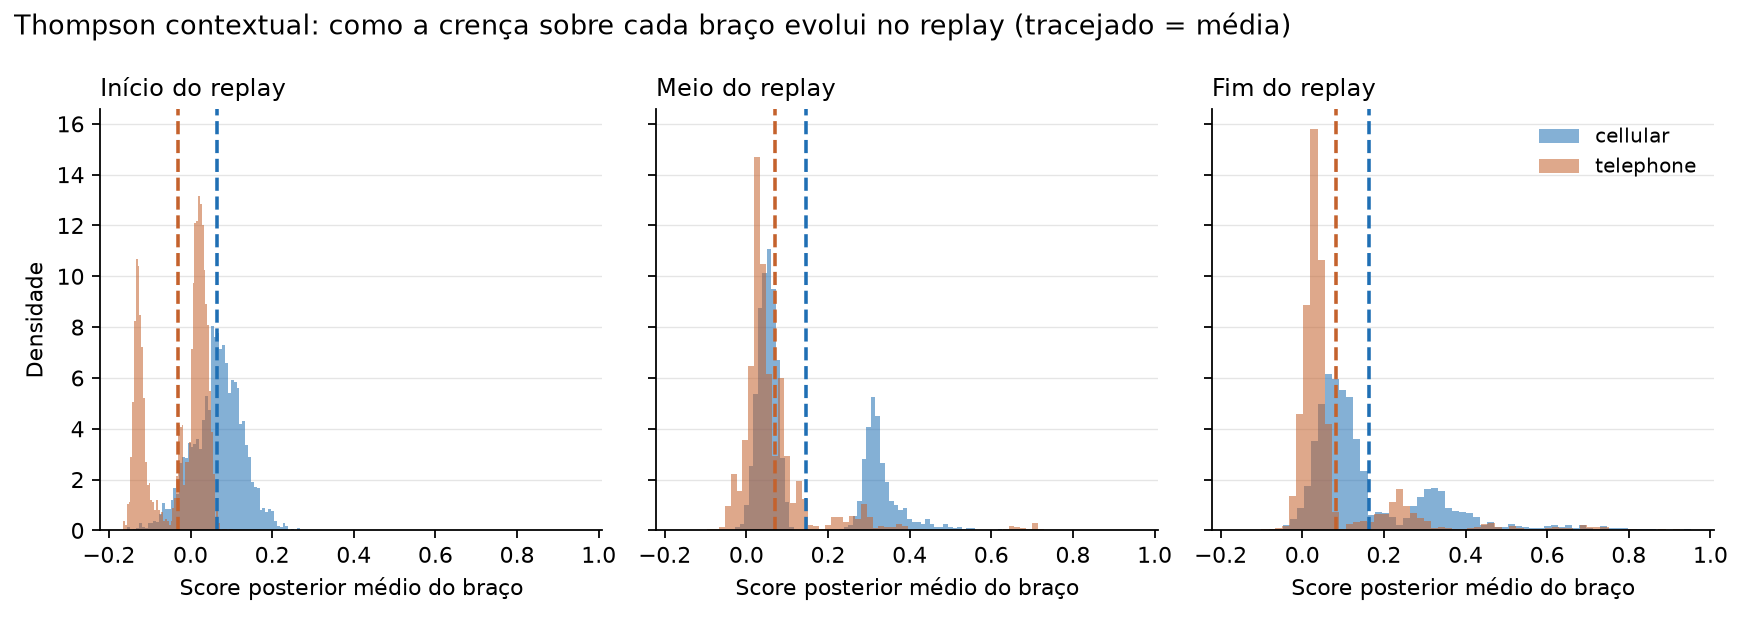

regret_acumulado.png


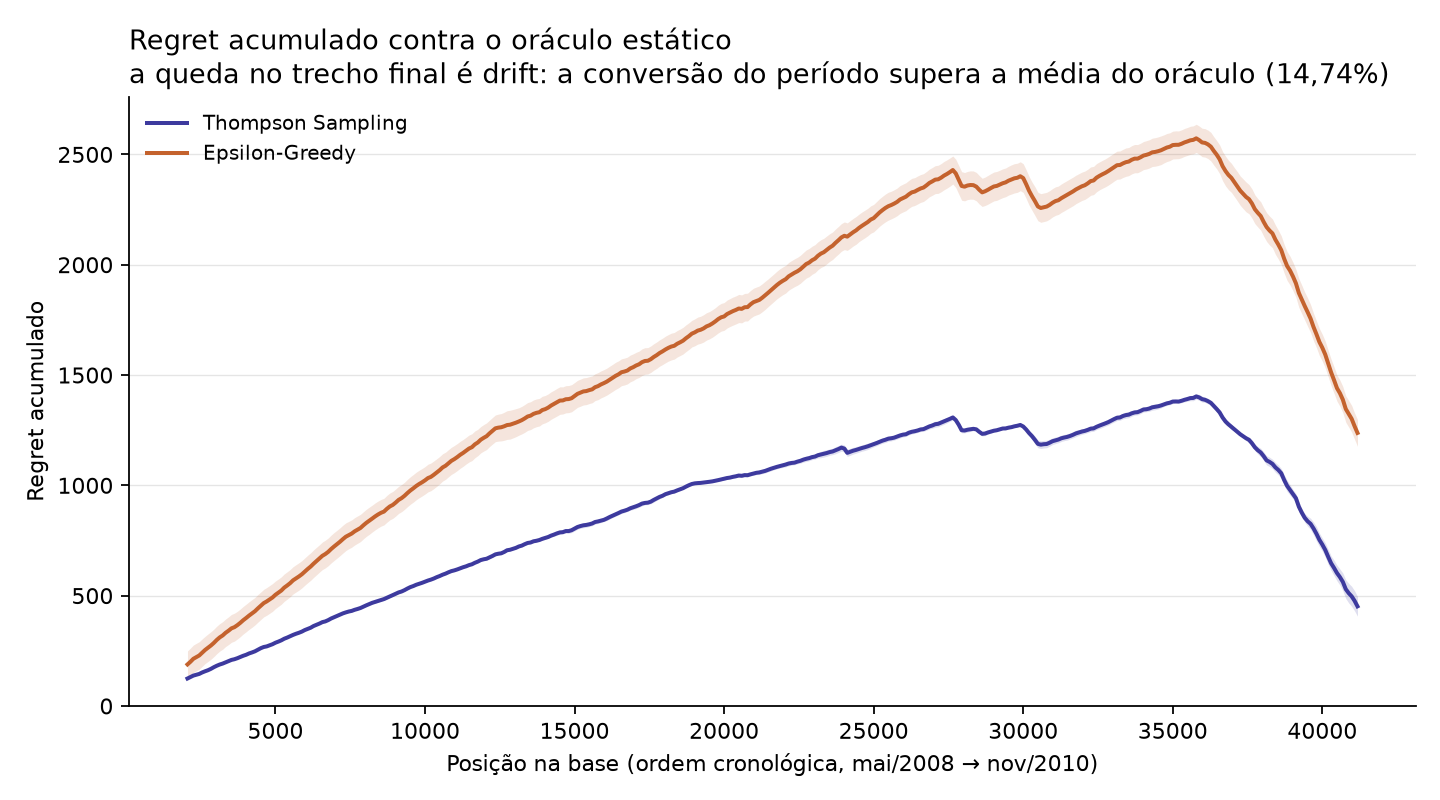

In [6]:
from pathlib import Path

from IPython.display import Image, display

for fig in [
    "conversao_acumulada.png",
    "escolha_por_braco.png",
    "posterior_thompson.png",
    "regret_acumulado.png",
]:
    caminho = Path("reports/figures") / fig
    if caminho.exists():
        print(fig)
        display(Image(filename=str(caminho)))